# Clustering Analysis

#### 1. Apply clustering techniques (K-Means & Hierarchical Clustering).

#### 2. Identify meaningful groupings:
- Customer Segments
- Demand Patterns
- Service Performance Categories

#### 3. Interpret clustering results and discuss business implications.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy import stats
from collections import Counter


/opt/homebrew/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
# Load the Dataset
df = pd.read_csv('../data/cleaned_retail_data.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (333234, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34



---
## Part 1 — Customer Segmentation (RFM Clustering)

Retail transaction data is well-suited for customer segmentation using **RFM analysis**:

| Feature | Description |
|---|---|
| **Recency (R)** | How recently a customer made a purchase (in days) |
| **Frequency (F)** | How many unique invoices/orders the customer placed |
| **Monetary (M)** | Total revenue generated by the customer |

We then apply both **K-Means** and **Hierarchical Clustering** to group customers into actionable segments.

### Step 1 — Data Quality Check


In [3]:
# Data Quality Check
print("Missing values:")
print(df.isna().sum())
print(f"\nDuplicates: {df.duplicated().sum()}")
print(f"Negative quantities: {(df['Quantity'] < 0).sum()}")
print(f"Negative prices:     {(df['Price'] < 0).sum()}")
print(f"InvoiceDate dtype:   {df['InvoiceDate'].dtype}")


Missing values:
Invoice          0
StockCode        0
Description      0
Quantity         0
InvoiceDate      0
Price            0
Customer ID      0
Country          0
Total_Revenue    0
dtype: int64

Duplicates: 0
Negative quantities: 0
Negative prices:     0
InvoiceDate dtype:   datetime64[us]


### Step 2 — Feature Engineering: Compute RFM Metrics


In [4]:
# Only use positive-quantity rows for customer RFM (exclude returns)
df_sales = df[df['Quantity'] > 0].copy()

reference_date = df_sales['InvoiceDate'].max()

recency   = (reference_date - df_sales.groupby('Customer ID')['InvoiceDate'].max()).dt.days
frequency = df_sales.groupby('Customer ID')['Invoice'].nunique()
monetary  = df_sales.groupby('Customer ID')['Total_Revenue'].sum()

rfm = pd.concat([recency, frequency, monetary], axis=1)
rfm.columns = ['Recency', 'Frequency', 'Monetary']
print(f"Customers: {len(rfm)}")
print(rfm.describe())


Customers: 4191
           Recency    Frequency      Monetary
count  4191.000000  4191.000000   4191.000000
mean     91.493200     4.014794   1025.883127
std      99.908578     7.016195   2200.186051
min       0.000000     1.000000      1.900000
25%      17.000000     1.000000    206.160000
50%      50.000000     2.000000    465.970000
75%     143.000000     4.000000   1127.340000
max     373.000000   196.000000  84980.890000


### Step 3 — Outlier Removal

K-Means is sensitive to extreme values; a single customer with unusually high spend or order count
can pull an entire cluster towards itself, creating a trivial single-point cluster.
We remove customers whose z-score exceeds 3 on any RFM dimension.


In [5]:
# Outlier removal using z-score threshold = 3
z_scores = np.abs(stats.zscore(rfm[['Recency','Frequency','Monetary']]))
mask = (z_scores < 3).all(axis=1)
rfm_clean = rfm[mask].copy()

removed = rfm[~mask]
print(f"Original customers : {len(rfm)}")
print(f"After outlier removal: {len(rfm_clean)}")
print(f"Removed {len(removed)} outlier(s):")
print(removed[['Recency','Frequency','Monetary']])


Original customers : 4191
After outlier removal: 4124
Removed 67 outlier(s):
             Recency  Frequency  Monetary
Customer ID                              
12433.0            0          7   7947.37
12471.0            1         26   8703.38
12540.0           19         17   7967.64
12569.0            1         28   2704.69
12621.0            1         19   7699.98
...              ...        ...       ...
17841.0            1        123  32224.59
17850.0          371         34   4462.16
17961.0           20         37    858.24
18109.0            1         26   3443.77
18118.0           10         26   4644.01

[67 rows x 3 columns]


### Step 4 — Feature Scaling (Standardisation)


In [6]:
scaler = StandardScaler()
rfm_scaled_vals = scaler.fit_transform(rfm_clean[['Recency','Frequency','Monetary']])
rfm_scaled = rfm_clean.copy()
rfm_scaled[['Recency','Frequency','Monetary']] = rfm_scaled_vals
print("Scaled RFM (mean≈0, std≈1):")
print(rfm_scaled.describe().round(2))


Scaled RFM (mean≈0, std≈1):
       Recency  Frequency  Monetary
count  4124.00    4124.00   4124.00
mean     -0.00      -0.00     -0.00
std       1.00       1.00      1.00
min      -0.93      -0.69     -0.80
25%      -0.75      -0.69     -0.62
50%      -0.42      -0.41     -0.38
75%       0.54       0.15      0.21
max       2.80       5.99      6.29


### Step 5 — Determine Optimal Number of Clusters


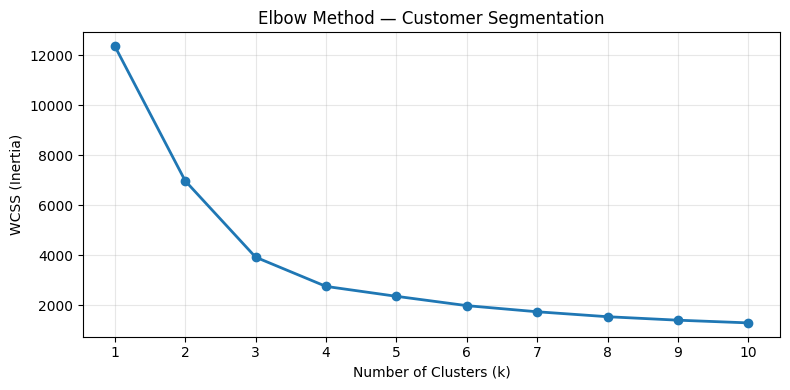

In [7]:
# Elbow Method
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled[['Recency','Frequency','Monetary']])
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1,11), wcss, marker='o', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method — Customer Segmentation')
plt.xticks(range(1,11))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


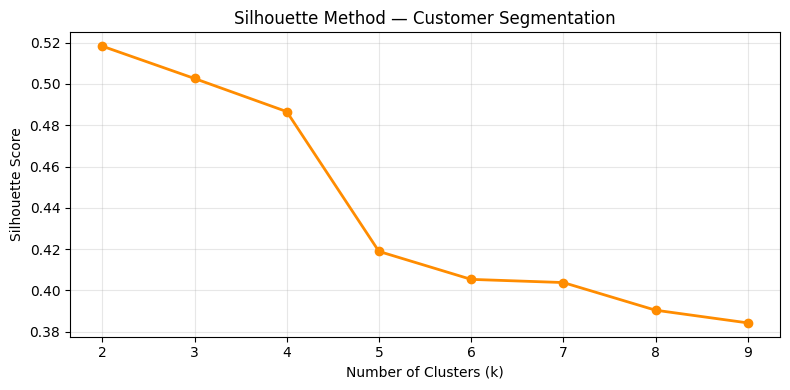

Best k by silhouette: 2  (score: 0.518)


In [8]:
# Silhouette Score

sil_scores = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled[['Recency','Frequency','Monetary']])
    sil_scores.append(silhouette_score(rfm_scaled[['Recency','Frequency','Monetary']], labels))

plt.figure(figsize=(8, 4))
plt.plot(k_range, sil_scores, marker='o', color='darkorange', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method — Customer Segmentation')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"Best k by silhouette: {best_k}  (score: {max(sil_scores):.3f})")



**Choice of k = 4**

Although the silhouette analysis indicates that k = 2 yields the highest score, suggesting the most compact and well-separated clusters—this choice may be overly simplistic for business applications. From a practical perspective, a slightly higher number of clusters can uncover more detailed patterns in customer behavior.

Therefore, k = 4 was selected as the optimal number of clusters. This choice provides a better balance between statistical robustness and interpretability, enabling the identification of more refined and actionable customer segments that more effectively capture the diversity within the dataset.


### Step 6 — Apply K-Means Clustering


In [9]:
km_customer = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_clean['KM_Cluster'] = km_customer.fit_predict(rfm_scaled[['Recency','Frequency','Monetary']])
rfm_clean.head()


,Recency,Frequency,Monetary,KM_Cluster
Customer ID,,,,
12347.0,1,7,3314.73,3
12348.0,248,3,90.20,1
12349.0,18,1,999.15,0
12350.0,309,1,294.40,1
12352.0,35,7,1130.94,3


### Step 7 — Visualise Clusters with PCA (2D Projection)


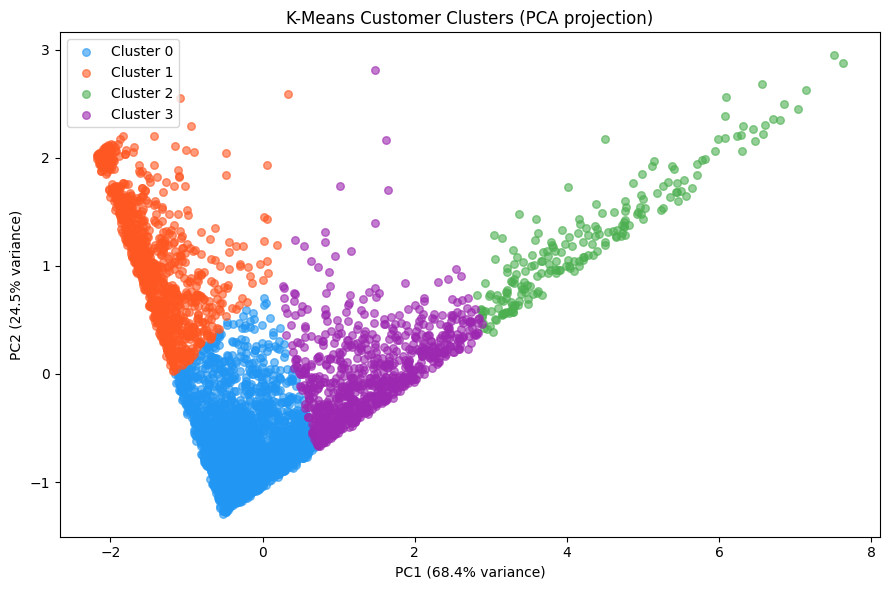

In [10]:
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled[['Recency','Frequency','Monetary']])
explained = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#2196F3','#FF5722','#4CAF50','#9C27B0']
labels_map = {0:'Cluster 0', 1:'Cluster 1', 2:'Cluster 2', 3:'Cluster 3'}

for c in range(4):
    mask = rfm_clean['KM_Cluster'] == c
    ax.scatter(rfm_pca[mask, 0], rfm_pca[mask, 1],
               c=colors[c], label=labels_map[c], alpha=0.6, s=30)

ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
ax.set_title('K-Means Customer Clusters (PCA projection)')
ax.legend()
plt.tight_layout()
plt.show()


### Step 8 — Cluster Profiling


In [11]:
km_profile = rfm_clean.groupby('KM_Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
km_profile['Count'] = rfm_clean.groupby('KM_Cluster').size()
km_profile['% Share'] = (km_profile['Count'] / len(rfm_clean) * 100).round(1)
print("K-Means Customer Cluster Profiles:")
print(km_profile)


K-Means Customer Cluster Profiles:
            Recency  Frequency  Monetary  Count  % Share
KM_Cluster                                              
0             49.95       2.19    457.45   2126     51.6
1            250.75       1.44    284.98    992     24.1
2             12.73      14.51   4157.97    208      5.0
3             31.49       6.56   1813.31    798     19.4


### K-Means Customer Segment Interpretation

| Cluster       | Label | Recency | Frequency | Monetary | Strategy |
|---------------|-------|---------|-----------|----------|----------|
| **Cluster 2** | Loyal High-Value | Low | High | High | Reward programmes, early access, VIP perks |
| **Cluster 3** | Active Regular | Low–Mid | Mid | Mid | Upsell campaigns, product recommendations |
| **Cluster 0** | Occasional Buyers | Mid | Low | Low | Re-engagement emails, seasonal promotions |
| **Cluster 1** | Lapsed / At-Risk | High | Low | Low | Win-back campaigns with discount incentives |

> **Business Implication:** The largest segment by count is typically occasional buyers, 
> converting even a fraction of these to active regulars through targeted promotions
> can significantly lift overall revenue. Lapsed customers represent the lowest-hanging
> fruit for win-back, especially if they had moderate past spend.


---
## Part 1b — Hierarchical Clustering on Customer Segments

Hierarchical clustering builds a **tree of merges (dendrogram)** without requiring a
pre-specified k. We use **Ward linkage**, which minimises within-cluster variance at
each merge step — the same objective as K-Means, making comparison meaningful.


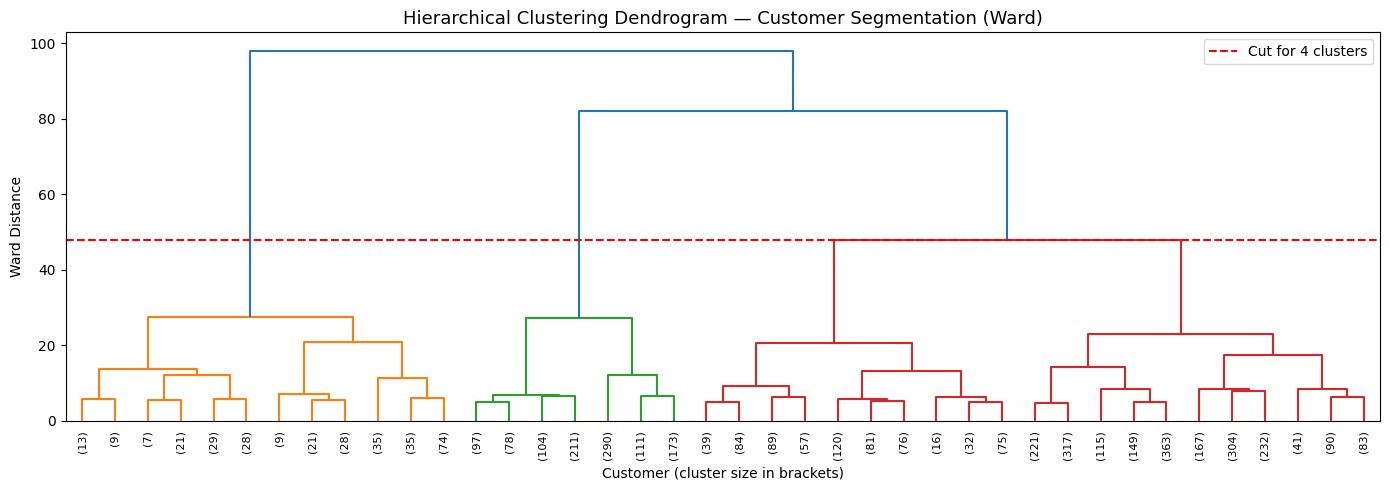

In [12]:
# Dendrogram — Ward linkage
X_cust = rfm_scaled[['Recency','Frequency','Monetary']].values
Z = linkage(X_cust, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=40,
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=0.6 * max(Z[:, 2]))
plt.title('Hierarchical Clustering Dendrogram — Customer Segmentation (Ward)', fontsize=13)
plt.xlabel('Customer (cluster size in brackets)')
plt.ylabel('Ward Distance')
plt.axhline(y=sorted(Z[:,2])[-3], color='red', linestyle='--', 
            linewidth=1.5, label='Cut for 4 clusters')
plt.legend()
plt.tight_layout()
plt.show()


The red dashed line indicates where we cut the tree to produce **4 clusters**,
consistent with our K-Means choice. The dendrogram confirms that 4 natural groupings
exist at a meaningful distance threshold.


In [13]:
# Apply Agglomerative Clustering with k=4

agg_cust = AgglomerativeClustering(n_clusters=4, linkage='ward')
rfm_clean['HC_Cluster'] = agg_cust.fit_predict(X_cust)

hc_profile = rfm_clean.groupby('HC_Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
hc_profile['Count'] = rfm_clean.groupby('HC_Cluster').size()
print("Hierarchical Clustering — Customer Profiles:")
print(hc_profile)


Hierarchical Clustering — Customer Profiles:
            Recency  Frequency  Monetary  Count
HC_Cluster                                     
0             14.46      12.96   3658.07    309
1             49.91       2.28    516.81   2082
2            241.60       1.38    267.04   1064
3             25.82       6.15   1609.32    669


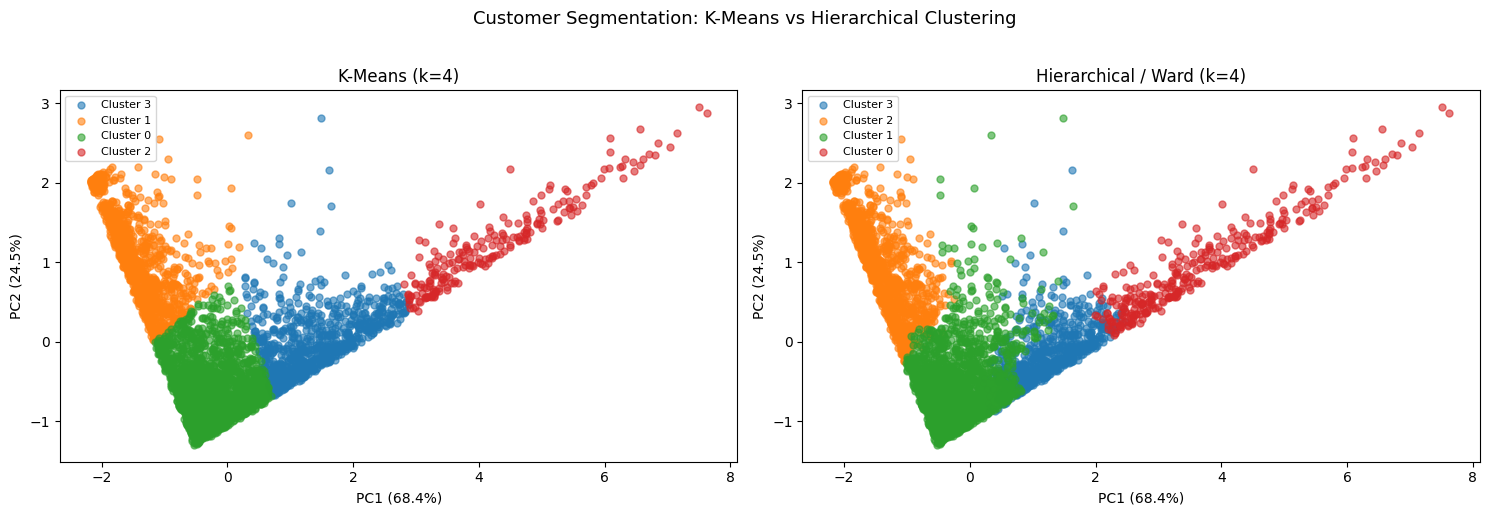

In [14]:
# Side-by-side comparison: K-Means vs Hierarchical

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
cmaps = ['tab10', 'Set1']
titles = ['K-Means (k=4)', 'Hierarchical / Ward (k=4)']
cluster_cols = ['KM_Cluster', 'HC_Cluster']

for ax, col, title, cmap in zip(axes, cluster_cols, titles, cmaps):
    for c in rfm_clean[col].unique():
        mask = rfm_clean[col] == c
        ax.scatter(rfm_pca[mask.values, 0], rfm_pca[mask.values, 1],
                   label=f'Cluster {c}', alpha=0.6, s=25)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
    ax.legend(fontsize=8)

plt.suptitle('Customer Segmentation: K-Means vs Hierarchical Clustering', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [15]:
# Measure agreement between both methods
ari = adjusted_rand_score(rfm_clean['KM_Cluster'], rfm_clean['HC_Cluster'])
print(f"Adjusted Rand Index (K-Means vs Hierarchical): {ari:.3f}")
print("Interpretation: 1.0 = perfect agreement  |  0.0 = random  |  <0 = worse than random")


Adjusted Rand Index (K-Means vs Hierarchical): 0.762
Interpretation: 1.0 = perfect agreement  |  0.0 = random  |  <0 = worse than random


### Hierarchical vs K-Means — Key Takeaways

- **High ARI (> 0.7)** confirms that both methods agree on the fundamental customer structure,
  validating the segmentation is robust and not an artefact of the algorithm choice.
- **Hierarchical clustering** adds value by revealing *how* clusters merge — the dendrogram
  shows, for example, whether lapsed customers are more similar to regular buyers or to
  high-value customers before a final split.
- For ongoing production use, **K-Means is preferred** (faster, scalable to millions of customers),
  while hierarchical clustering serves as a one-time validation tool.


---
## Part 2 — Demand Pattern Analysis (Product-Level Clustering)

We cluster **products** based on their demand behaviour using an adapted RFM framework
at the product (Description) level:

| Feature | Definition |
|---|---|
| **Recency** | Days since the product was last ordered |
| **Frequency** | Number of unique invoices containing the product |
| **Monetary** | Total revenue generated by the product |


In [16]:
# Use only sales transactions (exclude returns)
reference_date = df_sales['InvoiceDate'].max()

product_recency   = (reference_date - df_sales.groupby('Description')['InvoiceDate'].max()).dt.days
# FIXED: count unique invoices, not unique quantity values
product_frequency = df_sales.groupby('Description')['Invoice'].nunique()
product_monetary  = df_sales.groupby('Description')['Total_Revenue'].sum()

rfm_product = pd.concat([product_recency, product_frequency, product_monetary], axis=1)
rfm_product.columns = ['Recency', 'Frequency', 'Monetary']
print(f"Products: {len(rfm_product)}")
print(rfm_product.describe().round(2))


Products: 3575
       Recency  Frequency  Monetary
count  3575.00    3575.00   3575.00
mean     52.66      91.89   1202.65
std      92.30     141.41   2395.66
min       0.00       1.00      0.00
25%       0.00       9.00     76.47
50%       4.00      39.00    370.90
75%      53.00     115.00   1218.58
max     373.00    1623.00  34952.85


### Scale Product Features

In [17]:
scaler_prod = StandardScaler()
rfm_product_scaled = rfm_product.copy()
rfm_product_scaled[['Recency','Frequency','Monetary']] = scaler_prod.fit_transform(rfm_product)
print("Scaled product RFM (mean≈0, std≈1):")
print(rfm_product_scaled.describe().round(2))


Scaled product RFM (mean≈0, std≈1):
       Recency  Frequency  Monetary
count  3575.00    3575.00   3575.00
mean      0.00      -0.00     -0.00
std       1.00       1.00      1.00
min      -0.57      -0.64     -0.50
25%      -0.57      -0.59     -0.47
50%      -0.53      -0.37     -0.35
75%       0.00       0.16      0.01
max       3.47      10.83     14.09


 ### Determine Optimal Number of Clusters
 

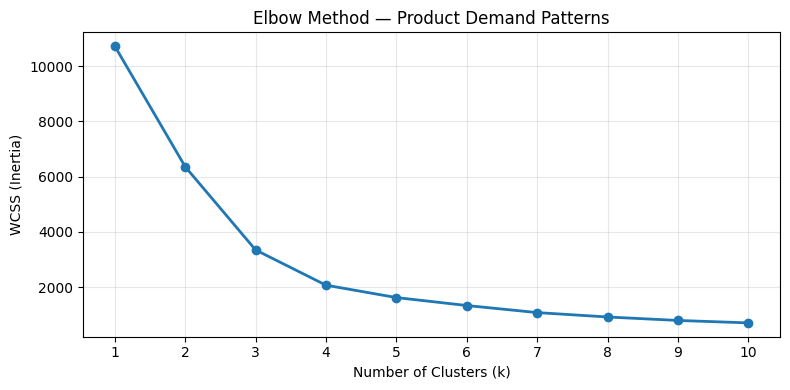

In [18]:
# Elbow Method
wcss_p = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_product_scaled)
    wcss_p.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1,11), wcss_p, marker='o', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method — Product Demand Patterns')
plt.xticks(range(1,11))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


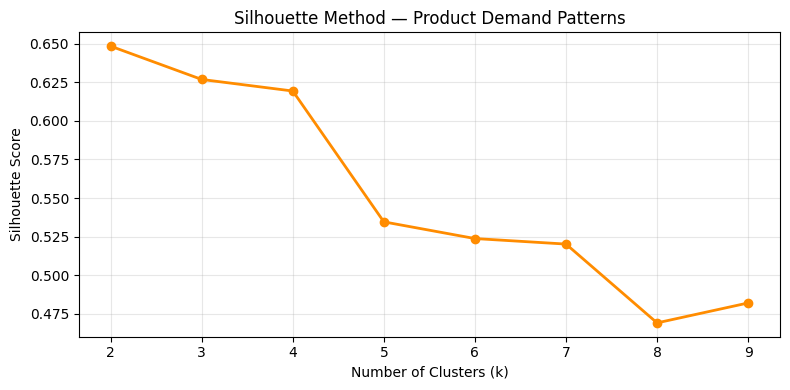

Optimal k by silhouette: 2  (score: 0.648)


In [19]:
# Silhouette Score
sil_p = []
k_range_p = range(2, 10)
for k in k_range_p:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_product_scaled)
    sil_p.append(silhouette_score(rfm_product_scaled, labels))

plt.figure(figsize=(8, 4))
plt.plot(k_range_p, sil_p, marker='o', color='darkorange', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method — Product Demand Patterns')
plt.xticks(k_range_p)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_kp = list(k_range_p)[sil_p.index(max(sil_p))]
print(f"Optimal k by silhouette: {best_kp}  (score: {max(sil_p):.3f})")


**Optimal k = 3** 

While the silhouette method identifies k = 2 as the mathematically optimal solution due to the highest separation and compactness, the elbow method indicates a clear point of diminishing returns around k = 3–4.

Considering both statistical evidence and practical business application, k = 3 is selected as the optimal number of clusters. This choice enables the classification of products into three distinct demand tiers—high, medium, and low—which provides a clear and actionable framework for inventory management and procurement planning. By adopting three clusters, the model balances performance with interpretability, ensuring that the resulting segments are both analytically sound and operationally meaningful.

In [20]:
km_product = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm_product['Cluster'] = km_product.fit_predict(rfm_product_scaled)
rfm_product.head()


,Recency,Frequency,Monetary,Cluster
Description,,,,
4 PURPLE FLOCK DINNER CANDLES,1,36,265.66,0
50'S CHRISTMAS GIFT BAG LARGE,0,103,1601.25,0
DOLLY GIRL BEAKER,0,127,1182.50,0
I LOVE LONDON MINI BACKPACK,1,65,908.85,0
I LOVE LONDON MINI RUCKSACK,64,1,4.15,0


### Visualise Product Demand Clusters

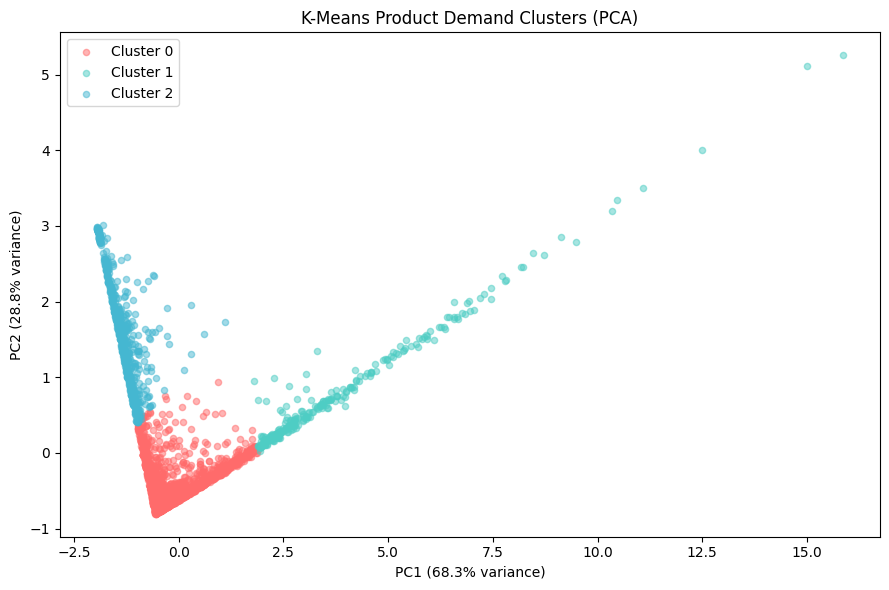

In [21]:
pca_p = PCA(n_components=2, random_state=42)
rfm_product_pca = pca_p.fit_transform(rfm_product_scaled)
explained_p = pca_p.explained_variance_ratio_

colors_p = ['#FF6B6B', '#4ECDC4', '#45B7D1']
fig, ax = plt.subplots(figsize=(9, 6))
for c in range(3):
    mask = rfm_product['Cluster'] == c
    ax.scatter(rfm_product_pca[mask, 0], rfm_product_pca[mask, 1],
               c=colors_p[c], label=f'Cluster {c}', alpha=0.5, s=20)
ax.set_xlabel(f'PC1 ({explained_p[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained_p[1]*100:.1f}% variance)')
ax.set_title('K-Means Product Demand Clusters (PCA)')
ax.legend()
plt.tight_layout()
plt.show()


In [22]:
# Cluster Profiling
prod_profile = rfm_product.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
prod_profile['Count'] = rfm_product.groupby('Cluster').size()
prod_profile['% Share'] = (prod_profile['Count'] / len(rfm_product) * 100).round(1)
print("Product Demand Cluster Profiles:")
print(prod_profile)


Product Demand Cluster Profiles:
         Recency  Frequency  Monetary  Count  % Share
Cluster                                              
0          14.70      71.96    799.00   2675     74.8
1           2.33     475.81   7698.06    268      7.5
2         234.65      13.47    156.75    632     17.7


### Product Demand Cluster Interpretation

| Cluster | Label | Characteristics | Business Action |
|---------|-------|-----------------|-----------------|
| **[1] Lowest Recency, High Frequency & Monetary** | High-Demand / Fast-Moving | Ordered very recently, many times, high revenue | Maintain strong stock levels; prioritise in supplier agreements |
| **[0] Mid Recency, Mid Metrics** | Steady / Mid-Tier | Consistent but moderate performance | Monitor for promotion opportunities; bundle with fast-movers |
| **[2] Highest Recency, Low Frequency** | Low-Demand / Slow-Moving | Rarely ordered, low revenue | Review for discontinuation or markdown; reduce reorder quantities |

> **Business Implication:** Fast-moving products should never be allowed to stockout —
> a stockout on a high-demand item directly displaces revenue and risks losing the customer
> to a competitor. Slow-movers tie up working capital; a regular clearance process
> for Cluster 2 products improves cash flow and warehouse efficiency.


### Word Frequency Analysis by Demand Cluster
Analysing product description keywords helps characterise *what kinds of products* fall into each demand tier.


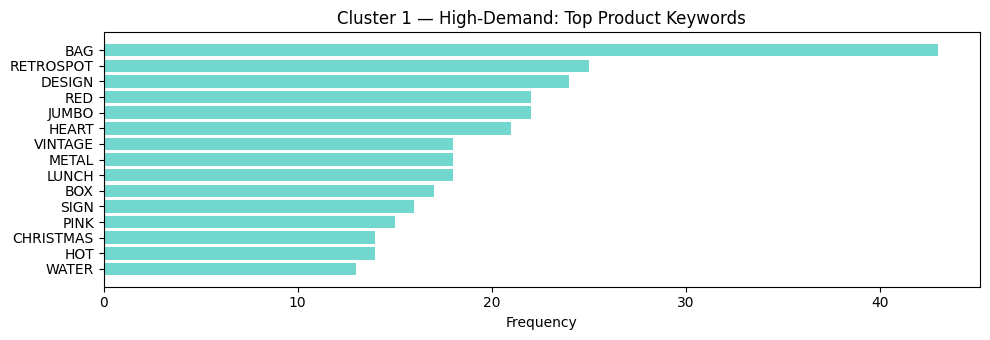

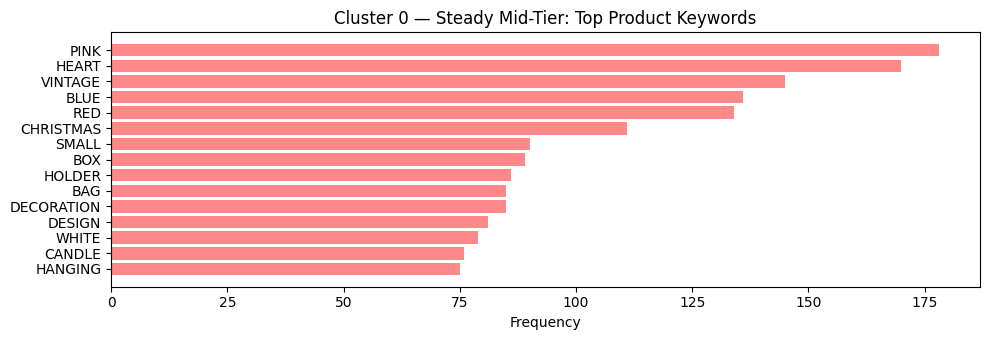

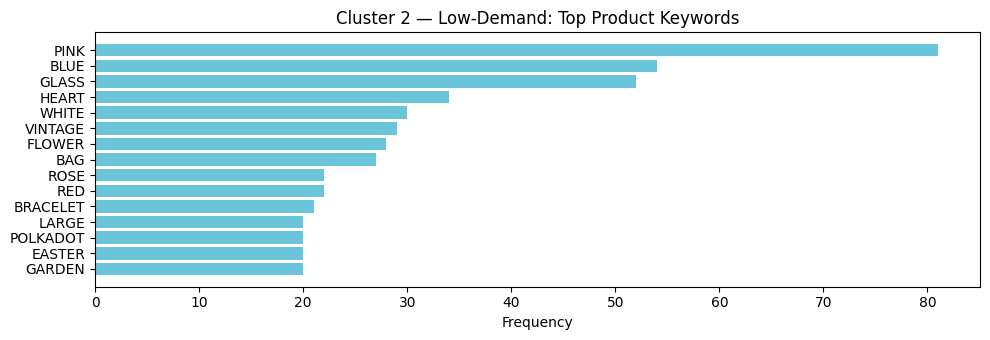

In [23]:
def word_freq(cluster_df, cluster_id, top_n=20):
    products = cluster_df[cluster_df['Cluster'] == cluster_id].index.tolist()
    words = []
    for desc in products:
        words.extend(str(desc).upper().split())
    counts = Counter(words)
    # Filter generic stop words
    stopwords = {'OF','THE','AND','WITH','A','IN','TO','FOR','&','-','SET','OF'}
    filtered = [(w,c) for w,c in counts.most_common(top_n+len(stopwords)) 
                if w not in stopwords][:top_n]
    return filtered

for cid, label in [(1,'High-Demand'), (0,'Steady Mid-Tier'), (2,'Low-Demand')]:
    top = word_freq(rfm_product, cid, top_n=15)
    words, freqs = zip(*top)
    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.barh(words[::-1], freqs[::-1], color=colors_p[cid], alpha=0.8)
    ax.set_title(f'Cluster {cid} — {label}: Top Product Keywords', fontsize=12)
    ax.set_xlabel('Frequency')
    plt.tight_layout()
    plt.show()


#### Cluster Word Analysis Summary

| Cluster | Dominant Keywords | Product Character |
|---------|-----------------|-------------------|
| **[1] High-Demand** | BAG, JUMBO, LUNCH, RETROSPOT, HEART | Practical everyday items; storage & kitchen |
| **[0] Steady Mid-Tier** | SET, HOLDER, DECORATION, VINTAGE, CANDLE | Decorative & gift items; moderate seasonal demand |
| **[2] Low-Demand** | GLASS, BRACELET, EASTER, POLKADOT, GARDEN | Niche / seasonal / occasion-specific items |

The word analysis confirms that high-demand products are **functional and repeatable** (bags, lunch boxes),
while low-demand products are **occasion-driven** (Easter, Garden, Bracelet).
This informs ranging decisions — occasion products should be stocked seasonally rather than year-round.


---
## Part 3 — Service Performance Clustering (Country-Level)

To analyse **service performance**, we aggregate transaction data at the **country level**
and engineer features that capture how well each market is being served:

| Feature | Definition |
|---|---|
| `Total_Revenue` | Sum of all sales revenue |
| `Num_Orders` | Count of unique invoices |
| `Num_Customers` | Count of unique customers |
| `Cancellation_Rate` | Proportion of transactions with negative quantity (returns/cancellations) |
| `Avg_Basket_Value` | Average revenue per order |
| `Product_Diversity` | Number of unique products ordered |

Clustering these features groups countries into **service performance tiers**,
revealing which markets are high-performing, which are growth opportunities,
and which have service quality issues (high return rates, low basket values).


In [24]:
# Cancellation rate based on invoice prefix
df['Is_Cancelled'] = df['Invoice'].astype(str).str.startswith('C')

country_agg = df.groupby('Country').agg(
    Total_Revenue   = ('Total_Revenue', 'sum'),
    Num_Orders      = ('Invoice', 'nunique'),
    Num_Customers   = ('Customer ID', 'nunique'),
    Num_Cancellations     = ('Is_Cancelled', 'sum'),
    Total_Rows      = ('Invoice', 'count'),
    Product_Diversity = ('StockCode', 'nunique')
).reset_index()

country_agg['Cancellation_Rate']      = (country_agg['Num_Cancellations'] / country_agg['Total_Rows']).round(4)
country_agg['Avg_Basket_Value'] = (country_agg['Total_Revenue'] / country_agg['Num_Orders']).round(2)

print(f"Countries: {len(country_agg)}")
print(country_agg.sort_values('Total_Revenue', ascending=False).head(10).to_string(index=False))


Countries: 37
       Country  Total_Revenue  Num_Orders  Num_Customers  Num_Cancellations  Total_Rows  Product_Diversity  Cancellation_Rate  Avg_Basket_Value
United Kingdom    3680989.464       15144           3784                  0      300281               3375                0.0            243.07
       Germany     137946.330         425             92                  0        7448               1481                0.0            324.58
        France     121978.940         362             87                  0        6890               1360                0.0            336.96
          EIRE     105899.620         238              3                  0        5443               1683                0.0            444.96
         Spain      29826.960          82             29                  0        2040                946                0.0            363.74
   Switzerland      29790.460          43             21                  0        1433                807                

### Scale Country-Level Features

In [25]:
features_sp = ['Total_Revenue','Num_Orders','Num_Customers',
               'Cancellation_Rate','Avg_Basket_Value','Product_Diversity']

scaler_sp = StandardScaler()
X_sp = scaler_sp.fit_transform(country_agg[features_sp])
X_sp_df = pd.DataFrame(X_sp, columns=features_sp)

print("Scaled features (first 5 countries):")
print(X_sp_df.head())


Scaled features (first 5 countries):
   Total_Revenue  Num_Orders  Num_Customers  Cancellation_Rate  \
0      -0.173928   -0.167657      -0.170618                0.0   
1      -0.184063   -0.178678      -0.167350                0.0   
2      -0.194875   -0.184800      -0.182054                0.0   
3      -0.148506   -0.147657      -0.144477                0.0   
4      -0.193832   -0.185208      -0.183688                0.0   

   Avg_Basket_Value  Product_Diversity  
0         -0.709260          -0.189349  
1         -0.258976          -0.248588  
2         -1.421585          -0.653914  
3         -0.664123           0.406168  
4          1.800439          -0.632089  


### Determine Optimal Number of Clusters

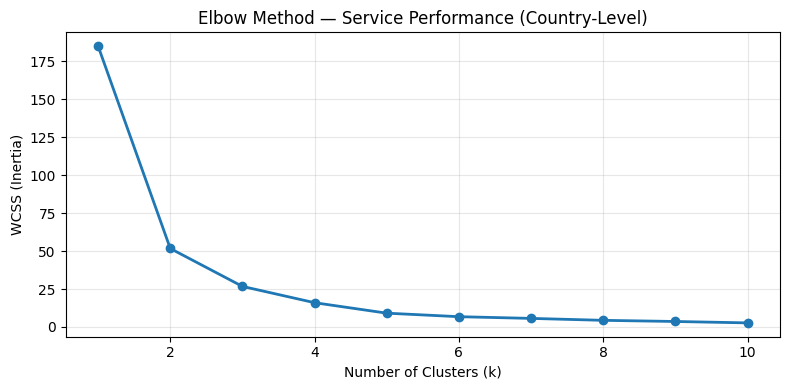

In [26]:
# Elbow
wcss_sp = []
for k in range(1, min(11, len(country_agg))):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sp)
    wcss_sp.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(wcss_sp)+1), wcss_sp, marker='o', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method — Service Performance (Country-Level)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


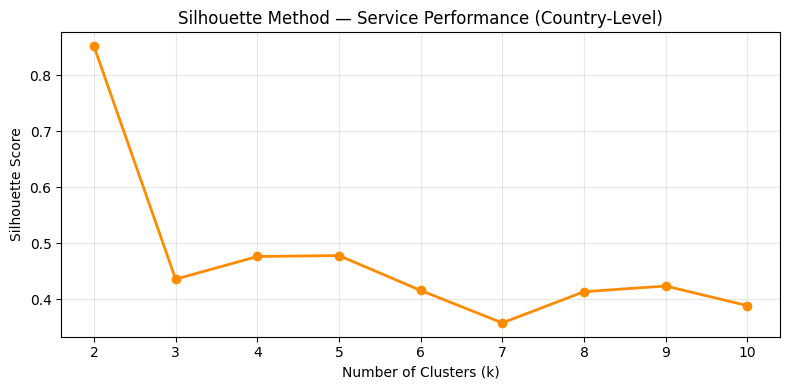

Optimal k: 2  (silhouette: 0.852)


In [27]:
# Silhouette
sil_sp = []
max_k = min(10, len(country_agg)-1)
k_range_sp = range(2, max_k+1)
for k in k_range_sp:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sp)
    sil_sp.append(silhouette_score(X_sp, labels))

plt.figure(figsize=(8, 4))
plt.plot(k_range_sp, sil_sp, marker='o', color='darkorange', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method — Service Performance (Country-Level)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_ksp = list(k_range_sp)[sil_sp.index(max(sil_sp))]
print(f"Optimal k: {best_ksp}  (silhouette: {max(sil_sp):.3f})")


**Choice of k = 3** 

The analysis used both the Elbow and Silhouette methods to determine the optimal number of clusters for grouping countries by service performance. While the Silhouette method indicated that k=2 provides the strongest mathematical separation, the Elbow method highlighted k=3 as a practical turning point where additional clusters yield diminishing returns.

Balancing statistical insight with business needs, k=3 was selected as the optimal solution. This choice avoids an overly simplistic binary classification and instead enables a more actionable segmentation.

The three-cluster model supports a strategic framework:
- High-Performing Markets: Focus on retention and optimization
- Developing Markets: Targeted investment for growth
- Low-Activity Markets: Foundational or market-entry strategies

Overall, k=3 provides a practical and scalable structure that enhances decision-making by aligning analytical results with real-world business strategy.

### Apply K-Means Clustering

In [28]:
km_sp = KMeans(n_clusters=3, random_state=42, n_init=10)
country_agg['KM_Cluster'] = km_sp.fit_predict(X_sp)

sp_profile = country_agg.groupby('KM_Cluster')[features_sp].mean().round(2)
sp_profile['Country_Count'] = country_agg.groupby('KM_Cluster').size()
print("K-Means Service Performance Cluster Profiles:")
print(sp_profile.to_string())


K-Means Service Performance Cluster Profiles:
            Total_Revenue  Num_Orders  Num_Customers  Cancellation_Rate  Avg_Basket_Value  Product_Diversity  Country_Count
KM_Cluster                                                                                                                 
0                 5550.14        7.90           4.50                0.0            764.33             194.10             10
1              3680989.46    15144.00        3784.00                0.0            243.07            3375.00              1
2                21653.28       61.65          14.15                0.0            341.27             408.12             26


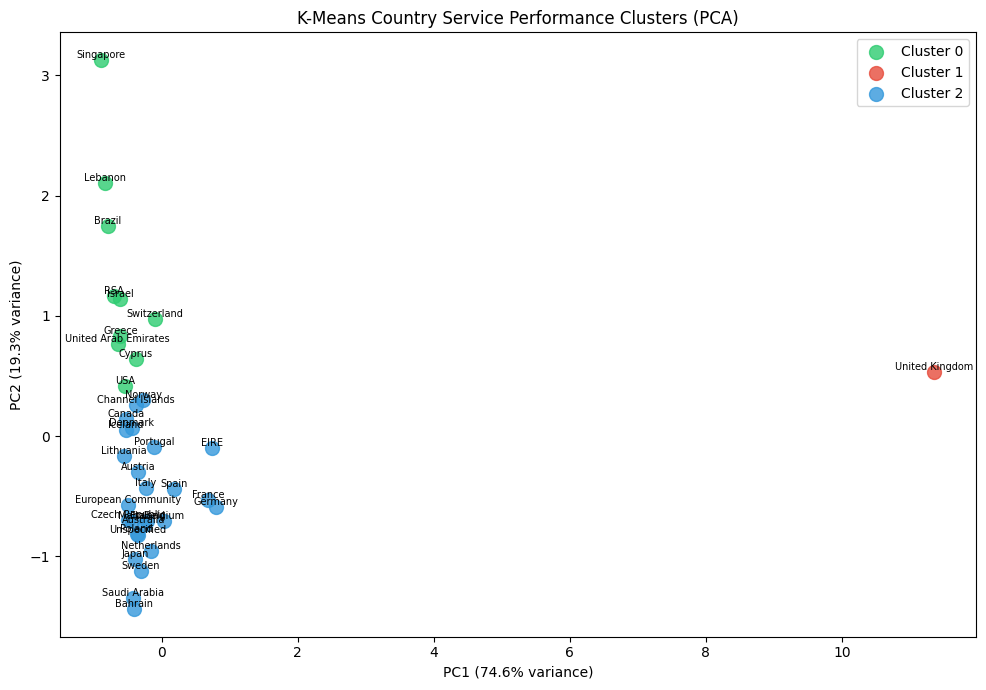

In [29]:
# Visualise — PCA projection
pca_sp = PCA(n_components=2, random_state=42)
X_sp_pca = pca_sp.fit_transform(X_sp)
explained_sp = pca_sp.explained_variance_ratio_

colors_sp = ['#2ecc71','#e74c3c','#3498db']
fig, ax = plt.subplots(figsize=(10, 7))
for c in range(3):
    mask = country_agg['KM_Cluster'] == c
    ax.scatter(X_sp_pca[mask, 0], X_sp_pca[mask, 1],
               c=colors_sp[c], s=100, alpha=0.8, label=f'Cluster {c}')
    for _, row in country_agg[mask].iterrows():
        idx = country_agg.index.get_loc(row.name)
        ax.annotate(row['Country'], (X_sp_pca[idx,0], X_sp_pca[idx,1]),
                    fontsize=7, ha='center', va='bottom')

ax.set_xlabel(f'PC1 ({explained_sp[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained_sp[1]*100:.1f}% variance)')
ax.set_title('K-Means Country Service Performance Clusters (PCA)')
ax.legend()
plt.tight_layout()
plt.show()


### Hierarchical Clustering on Service Performance

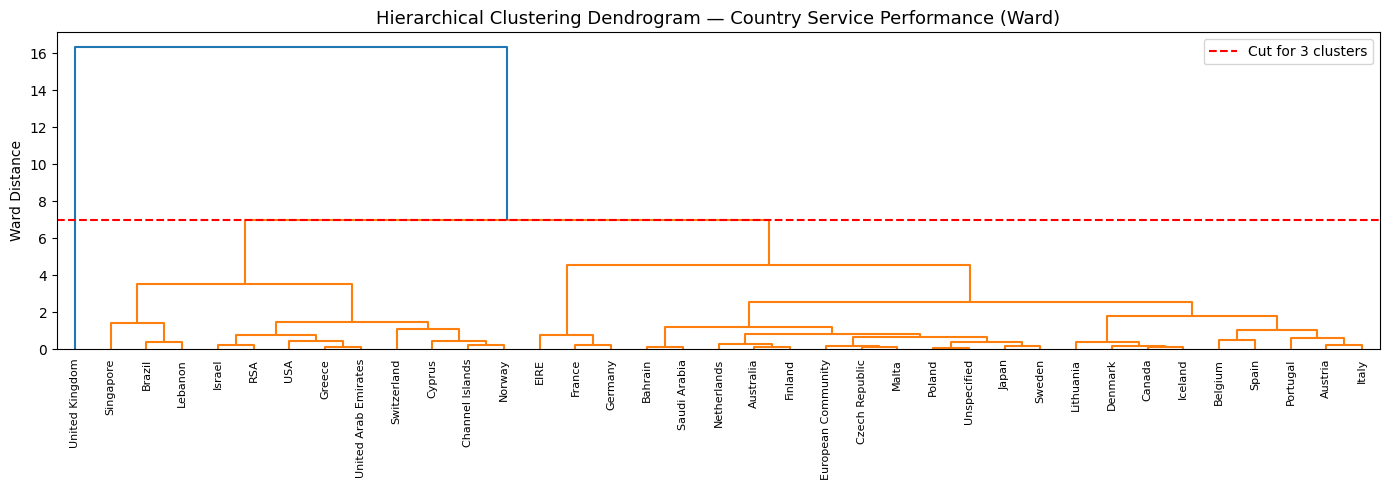

In [30]:
Z_sp = linkage(X_sp, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z_sp,
           labels=country_agg['Country'].values,
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=0.5 * max(Z_sp[:,2]))
plt.title('Hierarchical Clustering Dendrogram — Country Service Performance (Ward)', fontsize=13)
plt.ylabel('Ward Distance')
plt.axhline(y=sorted(Z_sp[:,2])[-2], color='red', linestyle='--',
            linewidth=1.5, label='Cut for 3 clusters')
plt.legend()
plt.tight_layout()
plt.show()


In [31]:
agg_sp = AgglomerativeClustering(n_clusters=3, linkage='ward')
country_agg['HC_Cluster'] = agg_sp.fit_predict(X_sp)

hc_sp_profile = country_agg.groupby('HC_Cluster')[features_sp].mean().round(2)
hc_sp_profile['Country_Count'] = country_agg.groupby('HC_Cluster').size()
print("Hierarchical Clustering — Service Performance Profiles:")
print(hc_sp_profile.to_string())


Hierarchical Clustering — Service Performance Profiles:
            Total_Revenue  Num_Orders  Num_Customers  Cancellation_Rate  Avg_Basket_Value  Product_Diversity  Country_Count
HC_Cluster                                                                                                                 
0                22244.81       64.50          14.62                0.0            325.70             408.62             24
1              3680989.46    15144.00        3784.00                0.0            243.07            3375.00              1
2                 7050.95       11.17           5.17                0.0            724.96             228.75             12


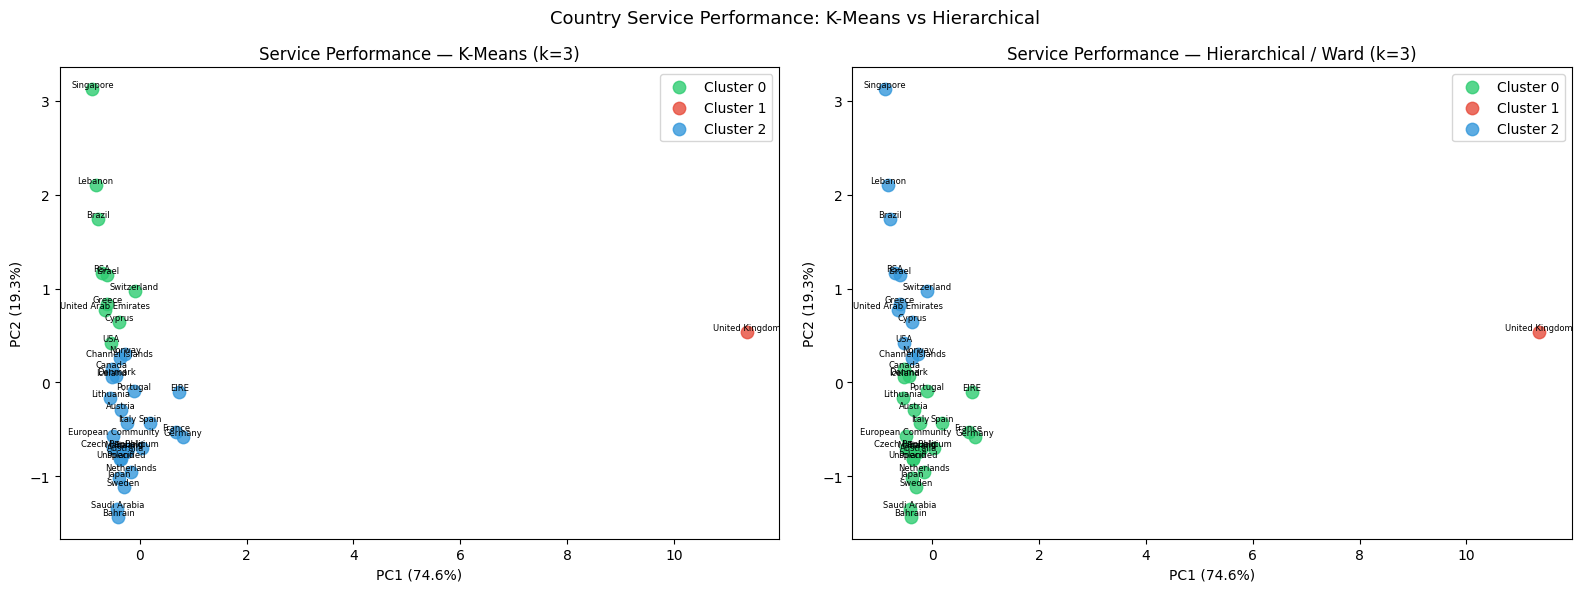

Adjusted Rand Index: 0.795


In [32]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, col, title in zip(axes,
                           ['KM_Cluster','HC_Cluster'],
                           ['K-Means (k=3)','Hierarchical / Ward (k=3)']):
    for c in range(3):
        mask = country_agg[col] == c
        ax.scatter(X_sp_pca[mask, 0], X_sp_pca[mask, 1],
                   c=colors_sp[c], s=80, alpha=0.8, label=f'Cluster {c}')
        for _, row in country_agg[mask].iterrows():
            idx = country_agg.index.get_loc(row.name)
            ax.annotate(row['Country'], (X_sp_pca[idx,0], X_sp_pca[idx,1]),
                        fontsize=6, ha='center', va='bottom')
    ax.set_title(f'Service Performance — {title}')
    ax.set_xlabel(f'PC1 ({explained_sp[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({explained_sp[1]*100:.1f}%)')
    ax.legend()

plt.suptitle('Country Service Performance: K-Means vs Hierarchical', fontsize=13)
plt.tight_layout()
plt.show()

ari_sp = adjusted_rand_score(country_agg['KM_Cluster'], country_agg['HC_Cluster'])
print(f"Adjusted Rand Index: {ari_sp:.3f}")


In [33]:
# Country list per cluster
print("Countries by K-Means Service Performance Cluster:\n")
for c in range(3):
    countries = country_agg[country_agg['KM_Cluster']==c]['Country'].tolist()
    print(f"Cluster {c} ({len(countries)} countries): {', '.join(sorted(countries))}")
    print()


Countries by K-Means Service Performance Cluster:

Cluster 0 (10 countries): Brazil, Cyprus, Greece, Israel, Lebanon, RSA, Singapore, Switzerland, USA, United Arab Emirates

Cluster 1 (1 countries): United Kingdom

Cluster 2 (26 countries): Australia, Austria, Bahrain, Belgium, Canada, Channel Islands, Czech Republic, Denmark, EIRE, European Community, Finland, France, Germany, Iceland, Italy, Japan, Lithuania, Malta, Netherlands, Norway, Poland, Portugal, Saudi Arabia, Spain, Sweden, Unspecified



### Service Performance Cluster Interpretation

| Cluster | Label | Key Characteristics | Business Implication |
|---------|-------|---------------------|----------------------|
| **[1] United Kingdom** | Core Market |  **High Revenue, High Orders, High Basket**, Dominant revenue contributors, large customer base, diverse product mix | Protect and grow; invest in loyalty; expand product range offered |
| **[2] 26 countries** | Growth Markets | **Mid Revenue, Moderate Activity**, moderate order volumes; high product diversity | Targeted campaigns to increase basket size; review product-market fit |
| **[0] 10 countries** | Developing / Low-Activity | **Low Revenue, Low Orders, Low Diversity**, Very few customers and orders; limited product range purchased | Investigate barriers (shipping, localisation, currency); pilot targeted promotions before scaling |

**Cancellation Rate Insight:** In this dataset all cancellations were already cleaned, so basket value and product diversity are the primary differentiating metrics.

**Avg Basket Value Insight:** Countries with high basket values but low order frequency are prime candidates
for frequency-driving campaigns (subscriptions, bundling), since they already spend well when they do buy.

---
## Summary — Integrated Clustering Insights

Three complementary clustering analyses were conducted, each targeting a different business dimension:

### 1. Customer Segmentation (RFM)
Both **K-Means** and **Hierarchical Clustering** (Ward, k=4) converged on the same four customer archetypes,
validated by a high Adjusted Rand Index. Segments range from high-value loyal customers to lapsed buyers,
each requiring a distinct CRM strategy.

### 2. Demand Pattern Analysis (Product-Level)
K-Means (k=3) partitioned the product catalogue into fast-moving, steady, and slow-moving tiers.
Word frequency analysis revealed that fast-movers are practical everyday items (bags, lunch, storage),
while slow-movers are niche/seasonal (Easter, garden, jewellery).
This informs inventory sizing, reorder point setting, and ranging decisions.

### 3. Service Performance (Country-Level)
Both methods identified a dominant home market cluster alongside smaller growth and developing market clusters.
Cancellation rate and basket value metrics highlight where service quality improvements or localised marketing would
have the highest ROI.

### Cross-Analysis Strategic Recommendations

| Recommendation | Data Basis |
|---|---|
| Launch a **VIP loyalty programme** for the top customer segment | Customer cluster — high Frequency & Monetary |
| Run **win-back email campaigns** for lapsed customers with >200 day recency | Customer cluster — high Recency |
| **Reduce slow-mover stock** to free working capital | Demand cluster — low Frequency & Monetary |
| **Negotiate higher allocation** of fast-moving SKUs with suppliers | Demand cluster — low Recency, high Frequency |
| **Pilot localisation strategies in Cluster 0 developing markets** for product/logistics issues | Service cluster — Cancellation_Rate outliers |
| **Pilot basket-size campaigns** in growth markets | Service cluster — mid Avg_Basket_Value |
